# Stateful channels: stream and fixed-point semantics

A channel diagram is **stateful** when some of its outputs are fed back into its
inputs one time step later. Such a diagram carries two semantics, and this page
takes them in turn:

1. **feedback loops** — what `feedback` builds and what the memory is;
2. **stream semantics** — `stream`, `now` and `unroll`, the behaviour at each
   finite time;
3. **fixed-point semantics** — `at_time` and `fix`, the state the loop settles
   into, approximated by `power` or `eigen` depending on the physics.

In [1]:
import numpy as np

from discopy.symmetric import Equation
from optyx import photonic
from optyx.channel import Channel, Discard, bit, qmode
from optyx.core import diagram

## 1. Feedback loops

`feedback` closes the last `mem` outputs into the last `mem` inputs, delayed by
one step. Here a photon enters at every step and the second output is fed back.

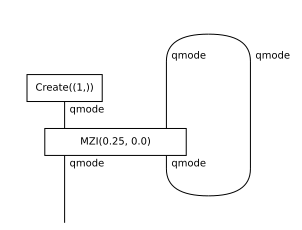

In [2]:
def loop(theta, phi=0.0):
    step = photonic.Create(1) @ qmode >> photonic.MZI(theta, phi)
    return step.feedback(mem=qmode, initial_state=photonic.Create(0))


loop(.25).draw(figsize=(4, 3))

In [3]:
print(f"dom={loop(.25).dom}  cod={loop(.25).cod}  mem={loop(.25).mem}")

dom=Ty()  cod=qmode  mem=qmode


## 2. Stream semantics

`stream` returns a `Stream`: the underlying `discopy.stream.Stream` and one
`FeedbackBoundary` per loop, in the order `unroll` uses them.

In [4]:
stream, boundaries = loop(.25).stream()
for boundary in boundaries:
    print(f"mem={boundary.mem}  initial_state={boundary.initial_state}  "
          f"final_effect={boundary.final_effect}")

mem=qmode  initial_state=Create((0,))  final_effect=None


The boundary is the **memory wire only**. The inputs and outputs of each tick
stay open — they are the domain and codomain of the stream at that tick.

`now` opens every loop again: one tick, from `dom @ mem` to `cod @ mem`.

qmode -> qmode @ qmode


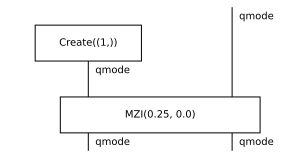

In [5]:
step = loop(.25).now()
print(f"{step.dom} -> {step.cod}")
step.draw(figsize=(4, 2))

`unroll(n)` stacks `n` ticks and plugs the boundaries in — the `initial_state`
before the first, the `final_effect` after the last. That is what the loop
becomes:

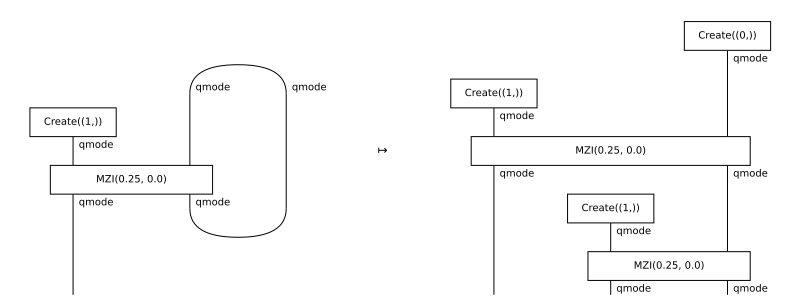

In [6]:
Equation(loop(.25), loop(.25).unroll(2), symbol=r"$\mapsto$").draw(
    figsize=(11, 4))

`stream` and `now` are methods, not properties. On a `discopy.stream.Stream`,
`now` and `mem` are fields of a value already built, so attribute syntax costs
nothing; only `later` is a property, and it forces the tail. Here nothing is
built yet: each call reinterprets the diagram to find the memory of every nested
loop, and a cached `.stream` property was considered and rejected, so attribute
syntax would promise a field and deliver a rebuild.

## 3. Fixed-point semantics

Both methods below need a **state** — an empty domain — and every loop needs an
`initial_state`. `at_time(n)` closes the loop for `n` ticks and discards
everything but the last output.

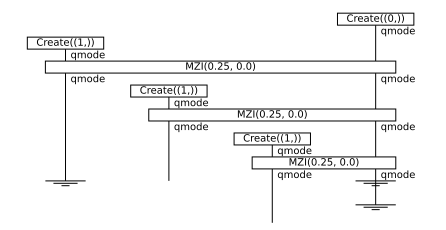

In [7]:
loop(.25).at_time(3).draw(figsize=(6, 3))

In [8]:
for n in (1, 2, 3, 8):
    measured = loop(.25).at_time(n) >> photonic.NumberResolvingMeasurement(1)
    p = measured.eval().prob_dist()
    print(f"n={n}  " + "  ".join(f"p({k[0]})={v:.4f}" for k, v in
                                 sorted(p.items())[:4]))

n=1  p(0)=0.5000  p(1)=0.5000
n=2  p(0)=0.5000  p(1)=0.2500  p(2)=0.2500
n=3  p(0)=0.4688  p(1)=0.2812  p(2)=0.1563  p(3)=0.0938


n=8  p(0)=0.4466  p(1)=0.2741  p(2)=0.1601  p(3)=0.0825


`fix` returns the limit of that sequence as an `EvalResult`, so `density_matrix`
and `prob_dist` read it like any other evaluation.

In [9]:
measured = loop(.06) >> photonic.NumberResolvingMeasurement(1)
stationary = measured.fix(method="eigen", chi=8)
print(type(stationary).__name__)
print("  ".join(f"p({k[0]})={v:.4f}"
                for k, v in sorted(stationary.prob_dist().items())[:5]))

EvalResult
p(0)=0.1241  p(1)=0.7587  p(2)=0.1105  p(3)=0.0067  p(4)=0.0000


In [10]:
def agreement(left, right):
    return max(abs(left.prob_dist().get(outcome, 0) - probability)
               for outcome, probability in right.prob_dist().items())


power = measured.fix(n_steps=12)
print(f"agreement with eigen: {agreement(power, stationary):.2e}")

agreement with eigen: 1.80e-16


### Which approximation, and when

| method | what it does | truncation `chi` | depth `n_steps` |
| --- | --- | --- | --- |
| `"power"` | contracts an unrolling as a tensor network | bond dimension, exact if `None` | unrolling depth |
| `"eigen"` | diagonalises the transfer matrix of one step | dimension of each memory wire | unused |

The physics decides. `eigen` needs the memory cutoff to hold the whole
stationary tail, so it refuses a loop that retains photons — at $\theta=0.25$
the beam splitter is balanced, the tail is long, and no reachable `chi` is
enough. `power` only has to reach the depth at which the unrolling has
converged, which a lossy or fast-mixing loop reaches quickly.

In [11]:
balanced = loop(.25) >> photonic.NumberResolvingMeasurement(1)
try:
    balanced.fix(method="eigen", chi=16)
except ValueError as error:
    print(f"eigen: {error}")
print("  ".join(f"p({k[0]})={v:.4f}" for k, v in
                sorted(balanced.fix(n_steps=8).prob_dist().items())[:4]))

eigen: The truncated transfer map is not causal (residual 0.00024414062500022204); increase cutoff.


p(0)=0.4466  p(1)=0.2741  p(2)=0.1601  p(3)=0.0825


`unroll_depth` turns a per-round-trip loss into a certified depth: a memory
losing a fraction `loss` each round trip forgets at least that much whatever the
loop does, so $n^\star=\lceil\log(tol)/\log(1-loss)\rceil$ holds for every
diagram. Passing `loss` to `fix` uses it instead of searching.

In [12]:
for loss in (.5, .1, .05):
    print(f"loss={loss:.2f}  n* = {loop(.25).unroll_depth(1e-6, loss):4d}")

loss=0.50  n* =   20
loss=0.10  n* =  132
loss=0.05  n* =  270


`stationary_state` is the solver underneath, defined for any loop-free
endomorphism rather than only for a feedback diagram.

In [13]:
from optyx import classical

transition = classical.ClassicalBox(
    "T", diagram.Box("T", diagram.bit, diagram.bit,
                     array=np.array([[.9, .1], [.4, .6]])), bit, bit)
print(transition.stationary_state())
print(f"causal: {transition.is_causal()}")

[0.8 0.2]
causal: True


### Feedback boson sampling

Let $U$ be a number-preserving unitary on $M+L$ modes. Every step injects a fixed
Fock state on the $M$ external inputs, detects $M$ outputs and feeds $L$ back.

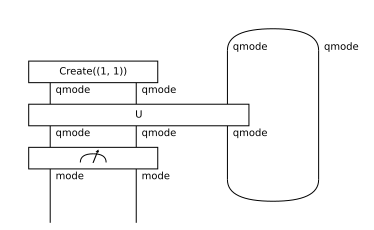

In [14]:
def haar(size, seed):
    rng = np.random.default_rng(seed)
    z = rng.normal(size=(size, size)) + 1j * rng.normal(size=(size, size))
    q, r = np.linalg.qr(z)
    return q * (np.diag(r) / np.abs(np.diag(r)))


M, L = 2, 1
U = photonic.Gate(haar(M + L, 7), M + L, M + L, "U")
sampler = (photonic.Create(*(1,) * M) @ qmode ** L >> U
           >> photonic.NumberResolvingMeasurement(M) @ qmode ** L
           ).feedback(mem=qmode ** L, initial_state=photonic.Create(0))
sampler.draw(figsize=(5, 3))

One step holds both maps: discarding the detected modes gives the **transfer**
channel that updates the loop, $\rho\mapsto\operatorname{Tr}_M[U(\psi\otimes\rho)
U^\dagger]$; discarding the next memory gives the **readout**. `fix` evolves the
memory to $\rho_\star$, then reads out once.

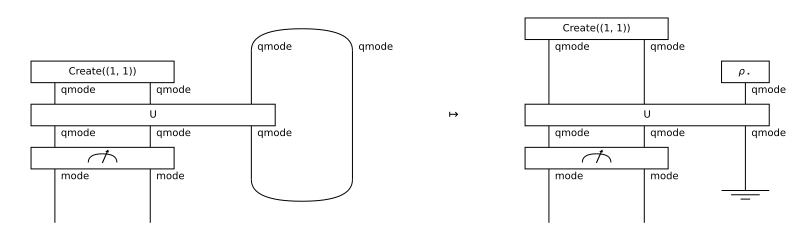

In [15]:
fixed = diagram.Box(r"$\rho_\star$", diagram.Ty(), diagram.Mode(2))
readout = (photonic.Create(*(1,) * M)
           @ Channel(r"$\rho_\star$", fixed, cod=qmode ** L,
                     env=diagram.Mode(1))
           >> U >> photonic.NumberResolvingMeasurement(M) @ Discard(qmode ** L))
Equation(sampler, readout, symbol=r"$\mapsto$").draw(figsize=(11, 3))

In [16]:
sampled = sampler.fix(method="eigen", chi=10)
for outcome, probability in sorted(
        sampled.prob_dist().items(), key=lambda item: -item[1])[:5]:
    print(f"p{outcome} = {probability:.4f}")
print(f"agreement with power: "
      f"{agreement(sampler.fix(n_steps=8), sampled):.2e}")

p(1, 0) = 0.1251
p(0, 0) = 0.1178
p(0, 1) = 0.1154
p(0, 2) = 0.1143
p(2, 0) = 0.1082


agreement with power: 6.66e-10


A real loop is a fibre, so each round trip transmits a fraction $\gamma$.
`PhotonLoss` puts that in the diagram, and the same $\gamma$ is the `loss` that
makes the depth a guarantee.

In [17]:
gamma = .5
lossy = (photonic.Create(*(1,) * M) @ qmode ** L >> U
         >> photonic.Id(M) @ photonic.PhotonLoss(gamma) ** L
         >> photonic.NumberResolvingMeasurement(M) @ qmode ** L
         ).feedback(mem=qmode ** L, initial_state=photonic.Create(0))
print(f"certified depth at tol=1e-3: "
      f"{lossy.unroll_depth(1e-3, loss=1 - gamma)}")
certified = lossy.fix(tol=1e-3, loss=1 - gamma)
print(f"agreement with eigen: "
      f"{agreement(certified, lossy.fix(method='eigen', chi=8)):.2e}")

certified depth at tol=1e-3: 10


agreement with eigen: 3.30e-15


That depth depends on $\gamma$ and the target accuracy alone — not on $U$, $M$ or
$L$. The bound behind it and its proof are in the wiki notebook *Bounding the
unroll length in approximate stationary boson sampling*.

## Further reading

The setup is Yu. A. Biriukov and I. V. Dyakonov, [Simulation of boson sampling
with optical feedback](https://doi.org/10.48550/arXiv.2602.05566),
arXiv:2602.05566 (2026); for boson sampling itself, S. Aaronson and A. Arkhipov,
[The computational complexity of linear
optics](https://doi.org/10.1145/1993636.1993682), STOC 2011.

Delayed feedback of a monoidal stream is E. Di Lavore, G. de Felice and M. Román,
[Monoidal streams for dataflow
programming](https://doi.org/10.1145/3531130.3533365), LICS 2022 — the memory
wire is a delay, which is what makes this feedback rather than a trace in the
sense of P. Katis, N. Sabadini and R. F. C. Walters, *Feedback, trace and
fixed-point semantics*, RAIRO-ITA **36** (2002).